## Setup

In [1]:
import yaml
import pathlib
import pickle as pk
import sys
sys.path.insert(1, "/Users/ian.convy/code/mmvaeplus/src")
import models as mmvae_models

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
import scipy.sparse as sprs

import utils
from data import MET_Data

In [2]:
def generate_2d_plot(exp_dict, fold, dataset, exps = [], data_map = []):
    pca_dict = {}
    for (exp_name, modal_dict) in exp_dict.items():
        all_latent = [z_mean for out_dict in modal_dict.values() for (z_mean, _, _) in out_dict.values()]
        pca_dict[exp_name] = PCA(2, svd_solver = "full").fit(np.concatenate(all_latent))
    plot_data = {"Experiment": [], "Input Modal": [], "Hue": [], "X": [], "Y": [], "Covariance": []}
    exps = exp_dict.keys() if not exps else exps
    for (exp_name, modal_dict) in exp_dict.items():
        if exp_name in exps:
            for (in_modal, folds) in modal_dict.items():
                (z_mean, z_transf, specimens) = folds[fold]
                cov = np.einsum("nij,nkj->nik", z_transf, z_transf)
                pca = pca_dict[exp_name]
                proj_mean = pca.transform(z_mean)
                proj_transf = np.einsum("nij,li,kj->nlk", cov, pca.components_, pca.components_)
                plot_data["Experiment"].extend([exp_name]*specimens.size)
                plot_data["Input Modal"].extend([in_modal]*specimens.size)
                plot_data["Hue"].extend(["null"]*specimens.size)
                plot_data["X"].extend(proj_mean[:, 0].tolist())
                plot_data["Y"].extend(proj_mean[:, 1].tolist())
                plot_data["Covariance"].extend(proj_transf)
                for (name, _, func) in data_map:
                    if func is not None:
                        plot_data.setdefault(name, []).extend(func(dataset, specimens).tolist())
    graph_maps = {"x": "X", "y": "Y", "col": "Input Modal", "hue": "Hue", **{elem: name for (name, elem, _) in data_map}}
    hue_categories = np.unique(plot_data[graph_maps["hue"]]).tolist()
    palette = sns.color_palette("husl", len(hue_categories))
    plot = sns.relplot(plot_data, **graph_maps, facet_kws={'sharey': "row", 'sharex': "row"},
                       hue_order = hue_categories, palette = palette)
    apply_covariances(plot, plot_data, graph_maps, hue_categories, palette)
    return plot

def apply_covariances(plot, plot_data, graph_maps, hue_categories, palette):
    col_data = plot_data[graph_maps["col"]]
    row_data = plot_data[graph_maps["row"]] if "row" in graph_maps else [None]*len(col_data)
    color_data = plot_data[graph_maps["hue"]]
    (eig_vals, eig_vecs) = np.linalg.eigh(plot_data["Covariance"])
    for info_tuple in zip(plot_data["X"], plot_data["Y"], eig_vals, eig_vecs, row_data, col_data, color_data):
        (x, y, (min_eig, max_eig), eig_vecs, row, col, color_cat) = info_tuple
        color = palette[hue_categories.index(color_cat)]
        angle = 180*np.arccos(eig_vecs[1, 0])/np.pi
        ellipse = Ellipse(xy = (x, y), width = 2*max_eig**0.5, height = 2*min_eig**0.5, angle = angle, edgecolor = color, fc = 'None', lw = 1)
        axis = plot.axes_dict[(row, col) if row else (col,)]
        axis.add_patch(ellipse)

def train_classifiers(classifiers, z, labels, is_train, count_thresh):
    num_train = is_train.sum()
    (z_train, z_test) = (z[is_train], z[~is_train])
    (y_train, y_test) = (labels[is_train], labels[~is_train])
    (classes, counts) = np.unique(y_train, return_counts = True)
    train_mask = np.isin(y_train, classes[counts > count_thresh])
    y_train_masked = y_train[train_mask]
    test_mask = np.isin(y_test, y_train_masked)
    y_test_masked = y_test[test_mask]
    (z_train_masked, z_test_masked) = (z_train[train_mask], z_test[test_mask])
    scores = [model.fit(z_train_masked, y_train_masked).score(z_test_masked, y_test_masked) for model in classifiers]
    return scores

merge_map = utils.get_tree_merge_map("../../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
def patch_color_code(dataset, specimens, index, merge_map = merge_map):
    color_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    cell_data = dataset.get_specimens(specimens, outputs = ["cluster_label"])
    color = color_func(np.char.strip(cell_data["cluster_label"]))
    return color

# Data

In [14]:
data_config = {
    "patchseq": {
        "path": "../../data/neurons.hdf5",
        "keys": {
            "logcpm": "logcpm", 
            "pca-ipfx": "pca-ipfx", 
            "arbors": "arbors"
        },
        "query": {"formats": [("logcpm", "pca-ipfx", "arbors")]},
        "modal_forms": {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"},
        "exclude": []
    },
    "polymnist": {
        "path": "../../data/polymnist.hdf5",
        "keys": {
            "m0": "m0",
            "m1": "m1",
            "m2": "m2",
            "m3": "m3",
            "m4": "m4",
        },
        "query": {},
        "modal_forms": {"A": "m0", "B": "m1", "C": "m2", "D": "m3", "E": "m4"},
        "exclude": []
    },
    "cub": {
        "path": "../../data/cub.hdf5",
        "keys": {
            "images": "images",
            "captions": "captions"
        },
        "query": {},
        "modal_forms": {"A": "images", "B": "captions"},
        "exclude": ["B"]
    }
}
datasets = {name: MET_Data(config["path"], **config["keys"]) for (name, config) in data_config.items()}

# Models

In [4]:
models = {}

## Ours

### Patch-seq

In [48]:
model_path = pathlib.Path("../../results/histograms/120_4_4_MET")
model_dict = utils.load_jit_folds(model_path)
modals = ["T", "E", "M"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        (mean, transf) = model.model_dict[input_modal]["enc"](X_tensors)
        return (mean, transf)
    folds[fold] = {
        "train_ids": fold_dict["train_ids"],
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("patchseq", {})["ours"] = folds


In [49]:
model_path = pathlib.Path("../../results/histograms/120_4_4_EM")
model_dict = utils.load_jit_folds(model_path)
modals = ["T", "E", "M"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        (mean, transf) = model.model_dict[input_modal]["enc"](X_tensors)
        return (mean, transf)
    folds[fold] = {
        "train_ids": fold_dict["train_ids"],
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("patchseq", {})["ours_full"] = folds


### PolyMNIST

In [6]:
model_path = pathlib.Path("../../results/polymnist/2_recon_10")
model_dict = utils.load_jit_folds(model_path)
modals = ["A", "B", "C", "D", "E"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, output_modals = modals):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        (mean, transf) = model.model_dict[input_modal]["enc"](X_tensors)
        return (mean, transf)
    folds[fold] = {
        "train_ids": fold_dict["train_ids"],
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("polymnist", {})["ours"] = folds


### CUB

In [7]:
model_path = pathlib.Path("../../results/cub/2_recon_10")
model_dict = utils.load_jit_folds(model_path)
modals = ["A", "B"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model, output_modals = modals):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        (mean, transf) = model.model_dict[input_modal]["enc"](X_tensors)
        return (mean, transf)
    folds[fold] = {
        "train_ids": fold_dict["train_ids"],
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("cub", {})["ours"] = folds


## MMVAE+

### Patch-seq

In [28]:
folds = {}
modal_indices = {"T": 0, "E": 1, "M": 2}
modal_forms = {"T": "logcpm", "E": "pca-ipfx", "M": "arbors"}
patch_folds = utils.load_jit_folds("../../results/baselines/t_e_arms")["folds"]
for fold in range(1, 11):
    try:
        mm_patch_path = f"/Users/ian.convy/code/mmvaeplus/outputs/Patch_2D_fold_{fold}/checkpoints/2_2_1.0_2/model_1000.rar"
        mm_patch_args = torch.load(f"/Users/ian.convy/code/mmvaeplus/outputs/Patch_2D_fold_{fold}/checkpoints/2_2_1.0_2/args.rar")
    except FileNotFoundError:
        break
    mm_patch_model = mmvae_models.MMVAEplus_Patch(mm_patch_args)
    mm_patch_model.load_state_dict(torch.load(mm_patch_path, map_location = torch.device("cpu")))
    mm_patch_model.eval()
    def func(X_dict, input_modal, model = mm_patch_model, modal_forms = modal_forms, modal_indices = modal_indices):
        in_arr = X_dict[modal_forms[input_modal]]
        input_vae = model.vaes[modal_indices[input_modal]]
        mm_z = input_vae(torch.from_numpy(in_arr).float())[0]
        return (mm_z.mean[..., 2:], torch.diag_embed(mm_z.variance[..., 2:]**0.5))
    folds[fold] = {
        "train_ids": patch_folds[fold]["train_ids"],
        "test_ids": patch_folds[fold]["test_ids"],
        "model": func,
        "modals": ["T", "E"]
    }
models.setdefault("patchseq", {})["mmvae"] = folds

### PolyMNIST

In [29]:
folds = {}
modal_indices = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
modal_forms = data_config["polymnist"]["modal_forms"]
mm_polymnist_path = "/Users/ian.convy/code/mmvaeplus/outputs/PolyMNIST_2D_fold_1/checkpoints/2_2_2.5_2/model_25.rar"
mm_polymnist_args = torch.load("/Users/ian.convy/code/mmvaeplus/outputs/PolyMNIST_2D_fold_1/checkpoints/2_2_2.5_2/args.rar")
mm_polymnist_model = mmvae_models.MMVAEplus_PolyMNIST_5modalities(mm_polymnist_args)
mm_polymnist_model.load_state_dict(torch.load(mm_polymnist_path, map_location = torch.device("cpu")))
mm_polymnist_model.eval()
patch_folds = utils.load_jit_folds("../../results/polymnist/64_recon_10")["folds"]
def func(X_dict, input_modal, model = mm_polymnist_model, modal_forms = modal_forms, modal_indices = modal_indices):
    in_arr = X_dict[modal_forms[input_modal]]
    input_vae = model.vaes[modal_indices[input_modal]]
    mm_z = input_vae(torch.from_numpy(in_arr).float().permute(0, 3, 1, 2).contiguous())[0]
    return (mm_z.mean[..., 2:], torch.diag_embed(mm_z.variance[..., 2:]**0.5))
poly_data = datasets["polymnist"]
train_ids = poly_data["specimen_id"][poly_data["train_test"] == "train"]
test_ids = poly_data["specimen_id"][poly_data["train_test"] == "test"]
folds[1] = {
    "train_ids": patch_folds[1]["train_ids"],
    "test_ids": patch_folds[1]["test_ids"],
    "model": func,
    "modals": ["A", "B", "C", "D", "E"]
}
models.setdefault("polymnist", {})["mmvae"] = folds

### CUB

In [30]:
folds = {}
modal_indices = {"A": 0, "B": 1}
modal_forms = data_config["cub"]["modal_forms"]
mm_cub_path = "/Users/ian.convy/code/mmvaeplus/outputs/CUB_2D_fold_1/checkpoints/2_2_1.0_2/model_10.rar"
mm_cub_args = torch.load("/Users/ian.convy/code/mmvaeplus/outputs/CUB_2D_fold_1/checkpoints/2_2_1.0_2/args.rar")
mm_cub_model = mmvae_models.MMVAEplus_CUB_Image_Captions(mm_cub_args)
mm_cub_model.load_state_dict(torch.load(mm_cub_path, map_location = torch.device("cpu")))
mm_cub_model.eval()
patch_folds = utils.load_jit_folds("../../results/cub/64_recon_10")["folds"]
def func(X_dict, input_modal, model = mm_cub_model, modal_forms = modal_forms, modal_indices = modal_indices):
    in_arr = X_dict[modal_forms[input_modal]]
    input_vae = model.vaes[modal_indices[input_modal]]
    if input_modal == "A":
        mm_z = input_vae(torch.from_numpy(in_arr).float().permute(0, 3, 1, 2).contiguous())[0]
    else:
        caption = torch.nn.functional.one_hot(torch.from_numpy(in_arr).long(), 1590)
        mm_z = input_vae(caption.float())[0]
    return (mm_z.mean[..., 2:], torch.diag_embed(mm_z.variance[..., 2:]**0.5))
cub_data = datasets["cub"]
train_ids = cub_data["specimen_id"][cub_data["train_test"] == "train"]
test_ids = cub_data["specimen_id"][cub_data["train_test"] == "test"]
folds[1] = {
    "train_ids": patch_folds[1]["train_ids"],
    "test_ids": patch_folds[1]["test_ids"],
    "model": func,
    "modals": ["A", "B"]
}
models.setdefault("cub", {})["mmvae"] = folds

## Contrastive Learning

### Patch-seq

In [231]:
model_path = pathlib.Path("../../results/contrast/patch_self")
model_dict = utils.load_jit_folds(model_path)
modals = ["T", "E"]
folds = {}
for (fold, fold_dict) in model_dict["folds"].items():
    model = fold_dict["best"]
    def func(X_dict, input_modal, model = model):
        X_tensors = {form: torch.from_numpy(arr).float() for (form, arr) in X_dict.items()}
        latent = model.model_dict[input_modal]["enc"](X_tensors)[0]
        latent_normed = latent / torch.linalg.norm(latent, dim = 1)[:, None]
        return (latent_normed, torch.diag_embed(torch.full_like(latent, 0.01)))
    folds[fold] = {
        "train_ids": fold_dict["train_ids"],
        "test_ids": fold_dict["test_ids"],
        "model": func,
        "modals": modals
    }
models.setdefault("patchseq", {})["contrast"] = folds


# Latent Space

In [10]:
max_count = 100
num_batches = {"patchseq": 1, "polymnist": 10, "cub": 20}
latent_results = {}
for (dataset_name, dataset_models) in models.items():
    met_data = datasets[dataset_name]
    query = data_config[dataset_name]["query"]
    modal_forms = data_config[dataset_name]["modal_forms"]
    batches = num_batches[dataset_name]
    latent_results[dataset_name] = {}
    for (model_name, folds) in dataset_models.items():
        for (fold, fold_dict) in folds.items():
            count = 0
            samples = met_data.query(fold_dict["test_ids"], **query, 
                                     outputs = ["specimen_id"] + list(modal_forms.values()))
            if "captions" in samples:
                samples["captions"] = samples["captions"][:, 0]
            for i in range(batches):
                if count >= max_count:
                    break
                batch_samples = {form: arr[i::batches][:max_count] for (form, arr) in samples.items()}
                specimen_ids = batch_samples.pop("specimen_id")
                count += len(specimen_ids)
                for (in_modal, in_form) in modal_forms.items():
                    print(f"Running {model_name} on {dataset_name}: {in_modal} -> {fold}               ", end = "\r")   
                    (z_mean, z_transf) = fold_dict["model"](batch_samples, in_modal)
                    (z_mean, z_transf) = (z_mean.numpy(force = True), z_transf.numpy(force = True))
                    latent_results[dataset_name].setdefault(model_name, {}).setdefault(in_modal, {}).setdefault(fold, []).append((z_mean, z_transf, specimen_ids))
        for (modal, folds) in latent_results[dataset_name][model_name].items():
            for (fold, latent_list) in folds.items():
                z_mean = np.concatenate([z for (z, _, _) in latent_list], 0)
                z_transf = np.concatenate([transf for (_, transf, _) in latent_list], 0)
                specimen_ids = np.concatenate([sp_id for (_, _, sp_id) in latent_list], 0)
                folds[fold] = (z_mean, z_transf, specimen_ids)

## Patch-seq

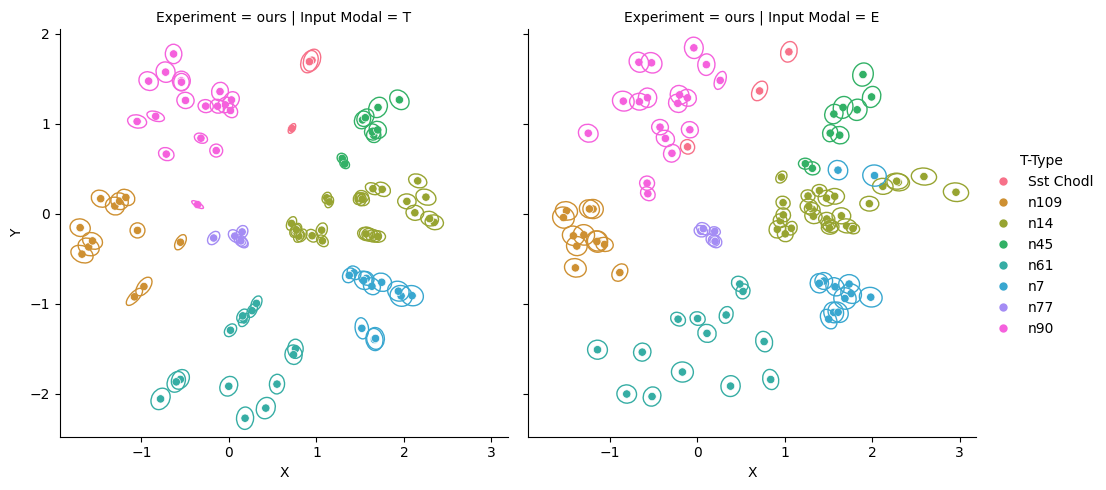

In [11]:

color_func = np.vectorize(lambda elem: merge_map[elem][-10]) 
data_map = {
    ("T-Type", "hue", lambda dataset,specimens: patch_color_code(dataset, specimens, -10)),
    ("Experiment", "row", None)
}
plot = generate_2d_plot(latent_results["patchseq"], 1, datasets["patchseq"], data_map = data_map)
plt.show()

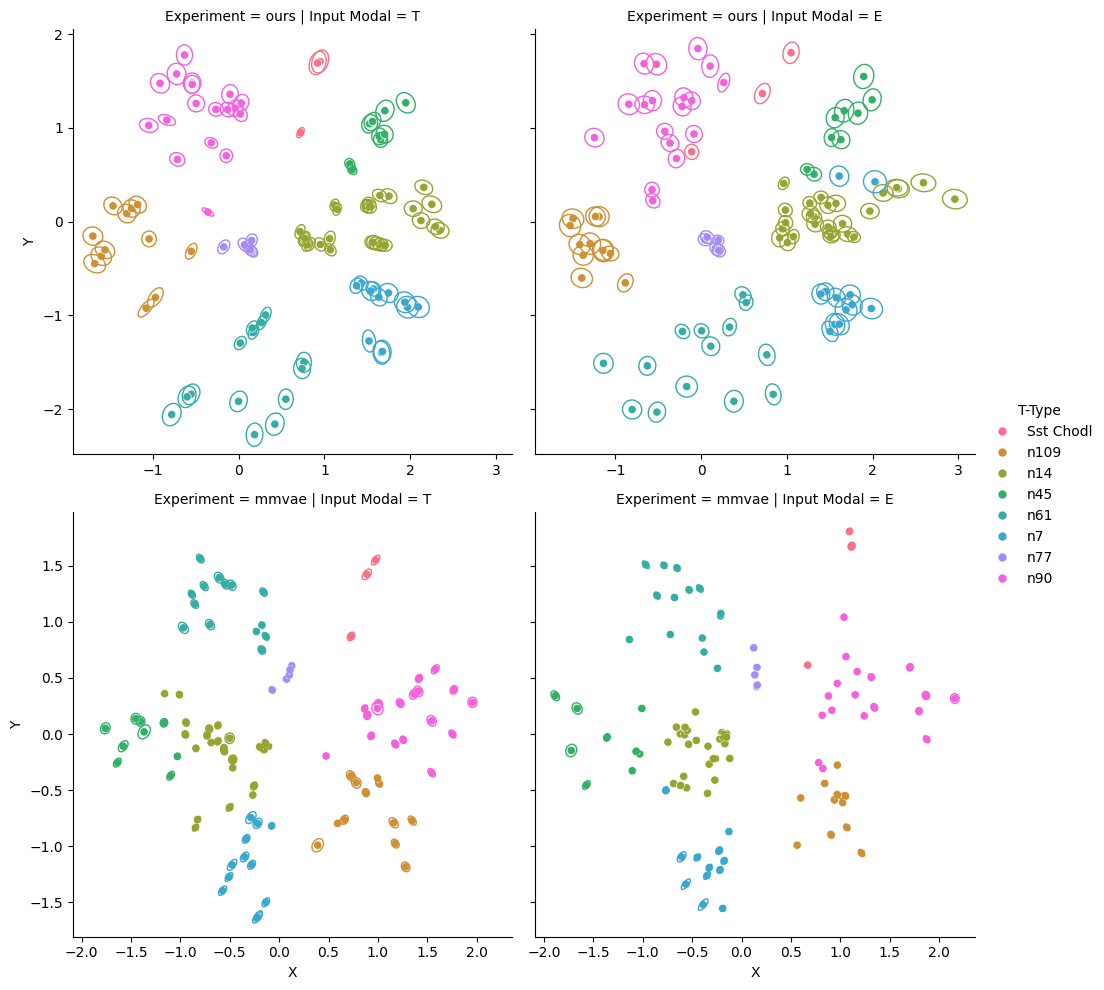

In [ ]:

color_func = np.vectorize(lambda elem: merge_map[elem][-10]) 
data_map = {
    ("T-Type", "hue", lambda dataset,specimens: patch_color_code(dataset, specimens, -10)),
    ("Experiment", "row", None)
}
plot = generate_2d_plot(latent_results["patchseq"], 1, datasets["patchseq"], data_map = data_map)
plt.show()

### PolyMNIST

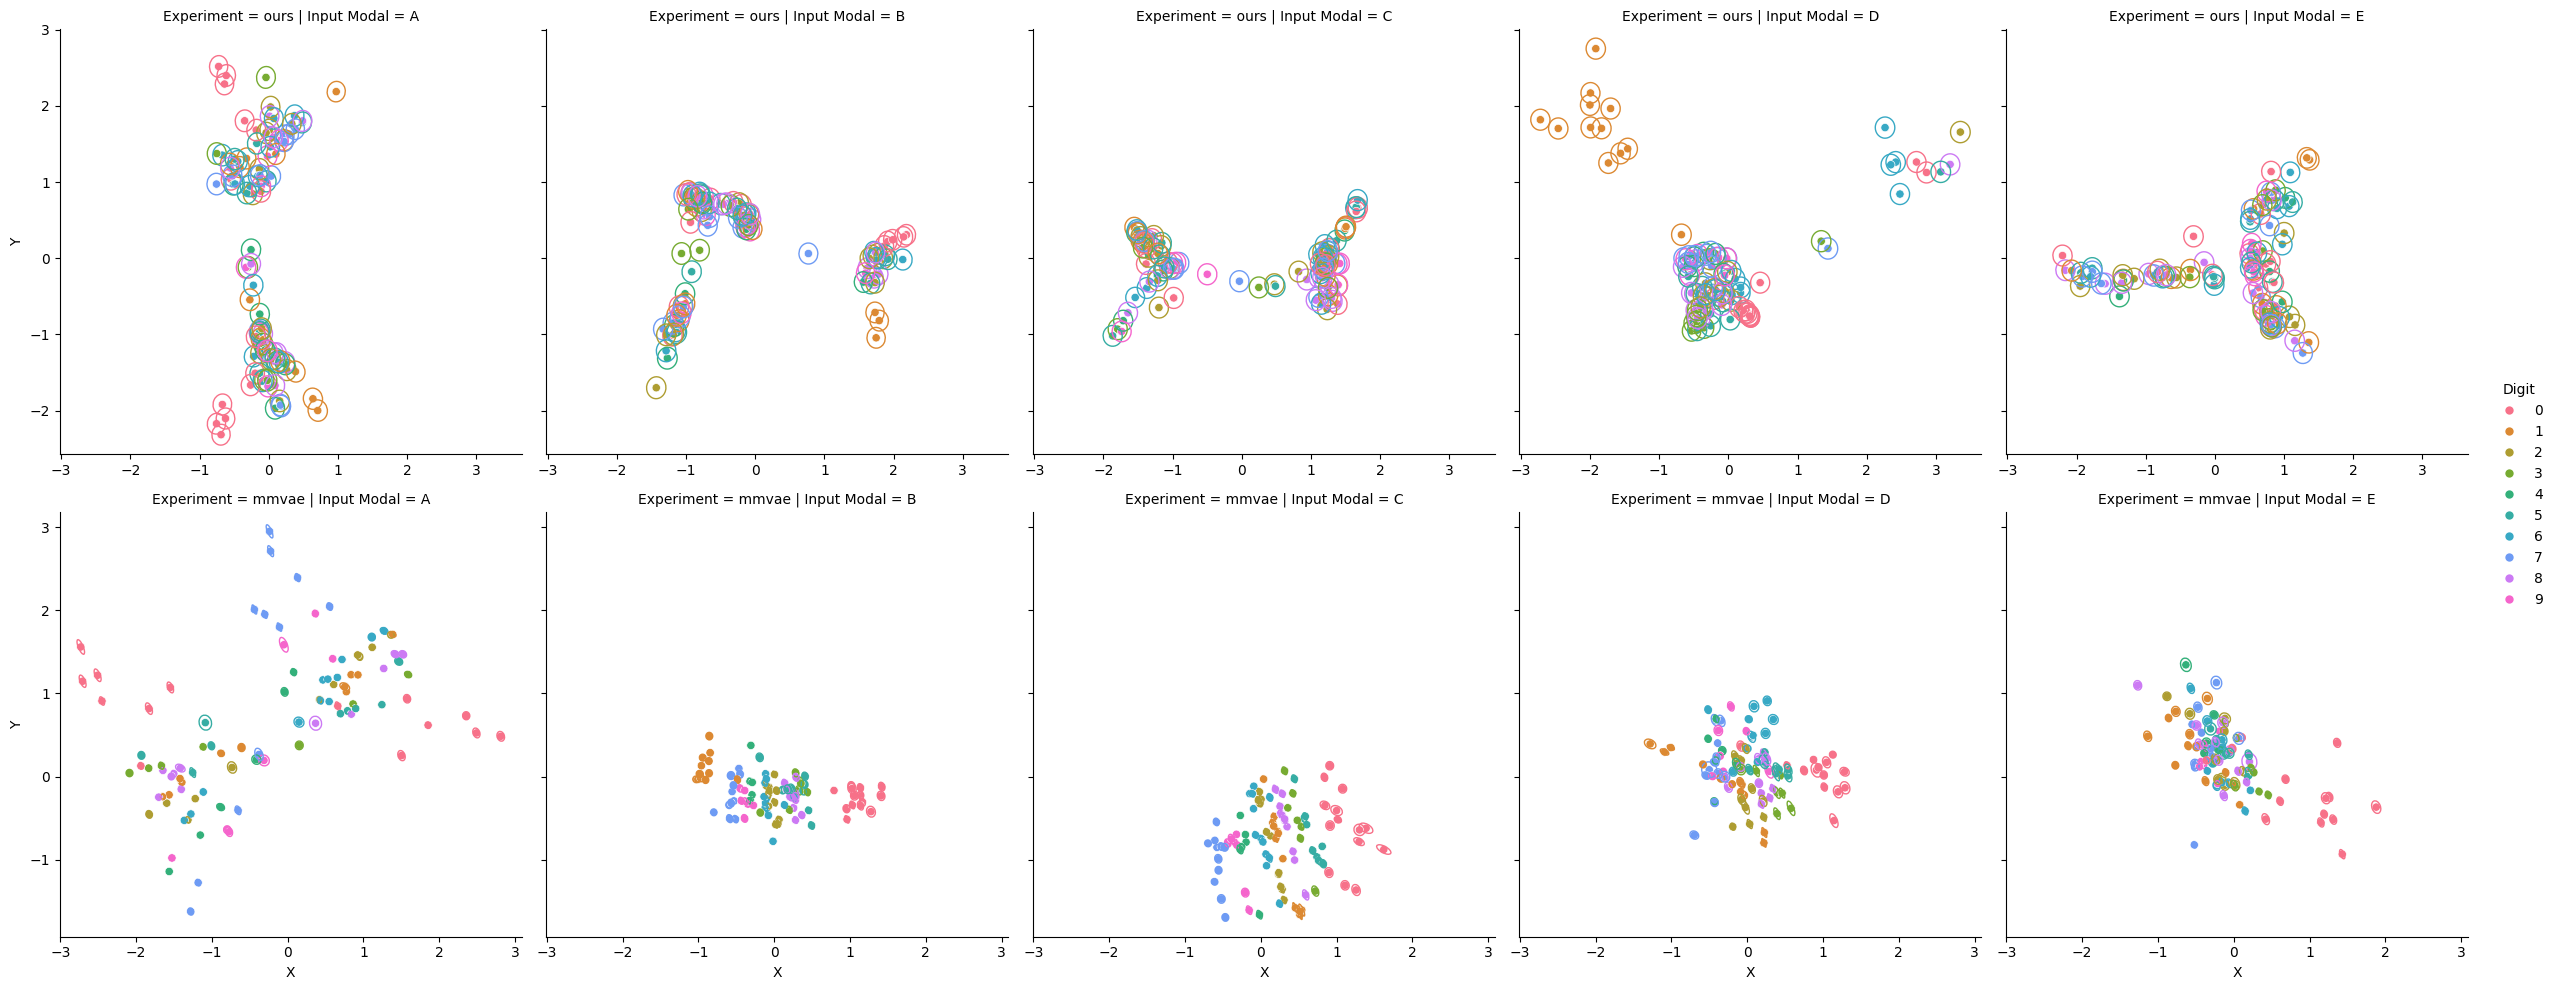

In [33]:
data_map = {
    ("Digit", "hue", lambda dataset,specimens: dataset.get_specimens(specimens, outputs = ["class"])["class"]),
    ("Experiment", "row", None)
}
plot = generate_2d_plot(latent_results["polymnist"], 1, datasets["polymnist"], data_map = data_map)
plt.show()

### CUB

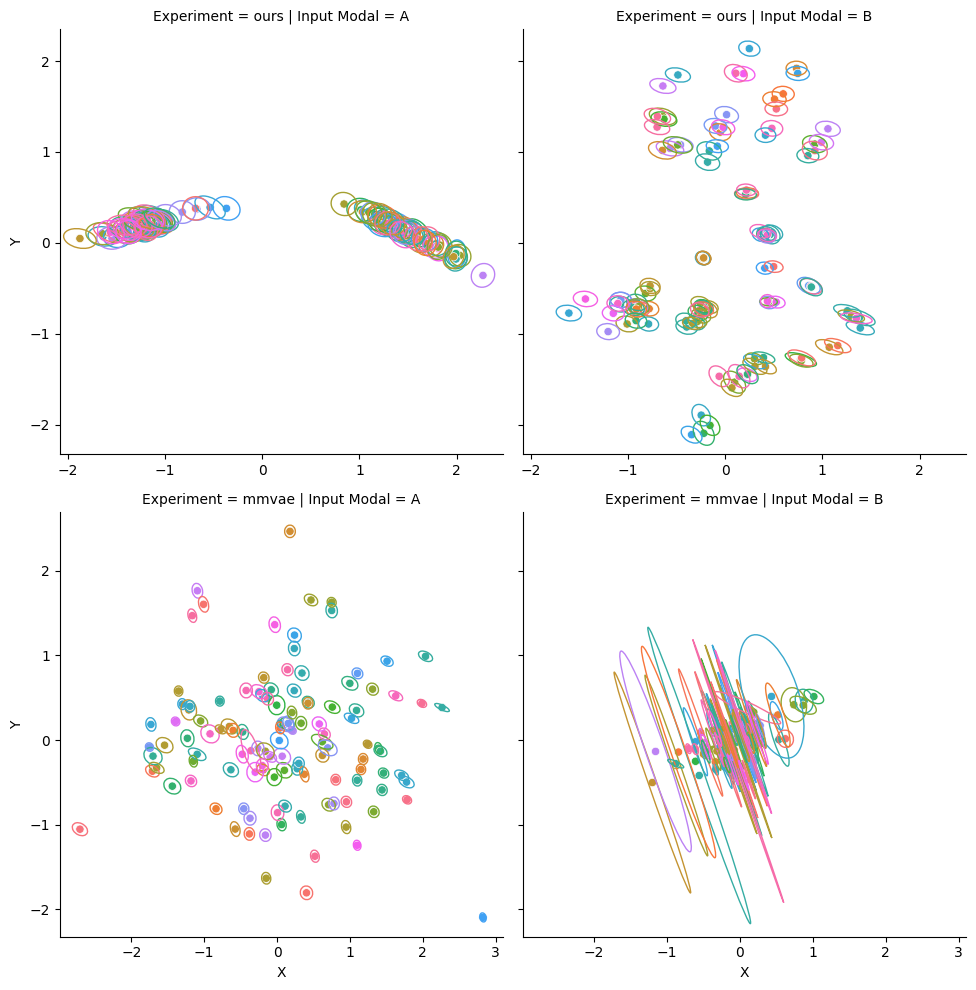

In [34]:
data_map = {
    ("Digit", "hue", lambda dataset,specimens: dataset.query(specimens, outputs = ["class"])["class"]),
    ("Experiment", "row", None)
}
plot = generate_2d_plot(latent_results["cub"], 1, datasets["cub"], data_map = data_map)
plot.legend.remove()
plt.show()

# Clustering

In [50]:
label_maps = {
    "patchseq": {i: lambda sp_ids,i=i: patch_color_code(datasets["patchseq"], sp_ids, i)
                 for i in range(100)},
    "polymnist": {0: lambda sp_ids: datasets["polymnist"].get_specimens(sp_ids, outputs = ["class"])["class"]},
    "cub": {0: lambda sp_ids: datasets["cub"].get_specimens(sp_ids, outputs = ["class"])["class"]}
}

In [51]:
allowed_models = {"ours", "ours_full"}
allowed_datasets = {"patchseq"}

In [52]:
accs = {}

In [53]:
num_batches = {"patchseq": 1, "polymnist": 70, "cub": 50}
for (dataset_name, dataset_models) in models.items():
    if dataset_name not in allowed_datasets: 
        continue
    met_data = datasets[dataset_name]
    query = data_config[dataset_name]["query"]
    modal_forms = data_config[dataset_name]["modal_forms"]
    batches = num_batches[dataset_name]
    accs[dataset_name] = {}
    for (model_name, folds) in dataset_models.items():
        if model_name not in allowed_models:
            continue
        for (fold, fold_dict) in folds.items():
            combined_ids = np.concatenate([fold_dict["train_ids"], fold_dict["test_ids"]])
            for (in_modal, in_form) in modal_forms.items():
                samples = met_data.query(combined_ids, **query, 
                                     outputs = ["specimen_id", modal_forms[in_modal]])
                if "captions" in samples:
                    samples["captions"] = samples["captions"][:, 0]
                for (map_index, map_func) in label_maps[dataset_name].items():
                    z_batches = []
                    for i in range(batches):
                        print(f"Running {model_name} on {dataset_name}: {in_modal} -> {fold} - {i + 1}/{batches} mapper {map_index}             ", end = "\r")
                        batch_samples = {form: arr[i::batches] for (form, arr) in samples.items()}
                        specimen_ids = batch_samples.pop("specimen_id")  
                        z = fold_dict["model"](batch_samples, in_modal)[0].numpy(force = True)
                        labels = map_func(specimen_ids)
                        is_train = np.isin(specimen_ids, fold_dict["train_ids"])
                        z_batches.append((z, labels, is_train))
                    z = np.concatenate([z for (z, _, _) in z_batches], 0)
                    labels = np.concatenate([y for (_, y, _) in z_batches], 0)
                    is_train = np.concatenate([mask for (_, _, mask) in z_batches], 0)
                    classifiers = [QDA(reg_param=1e-2, store_covariance=True)]
                    scores = train_classifiers(classifiers, z, labels, is_train, count_thresh = 6)
                    accs[dataset_name].setdefault(model_name, {}).setdefault(in_modal, {}).setdefault(map_index, {})[fold] = scores[0]

## Patch-seq

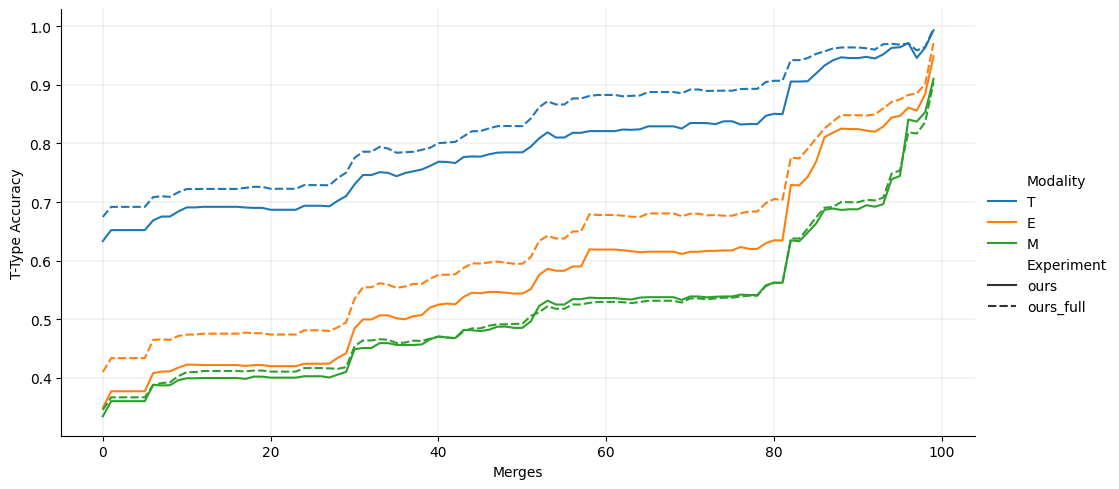

In [54]:
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["patchseq"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None, aspect = 2)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.savefig("test.png", dpi = 1000.0)
plt.show()

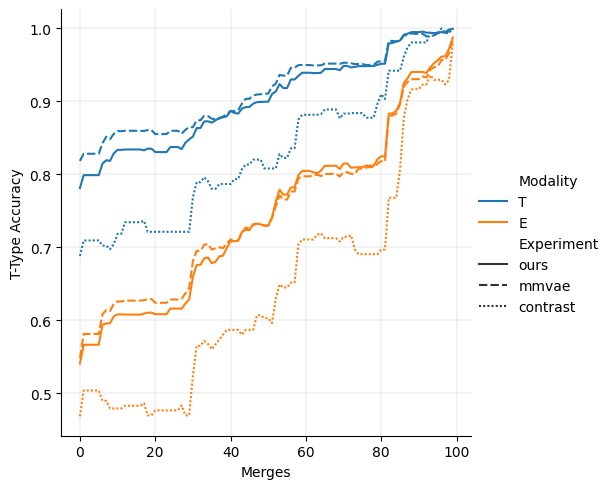

In [ ]:
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["patchseq"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.show()

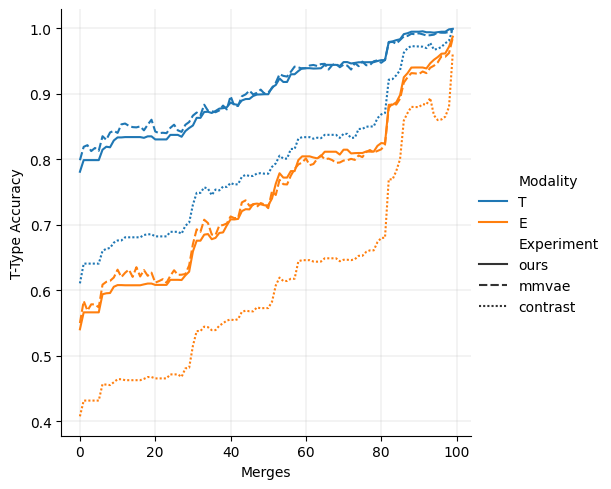

In [ ]:
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["patchseq"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.show()

## PolyMNIST

In [242]:
accs.keys()

dict_keys(['patchseq'])

In [241]:
results = {"Digit Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["polymnist"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Digit Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.catplot(results, x = "Modality", y = "Digit Accuracy", hue = "Experiment",
                   kind = "bar", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.show()

KeyError: 'polymnist'

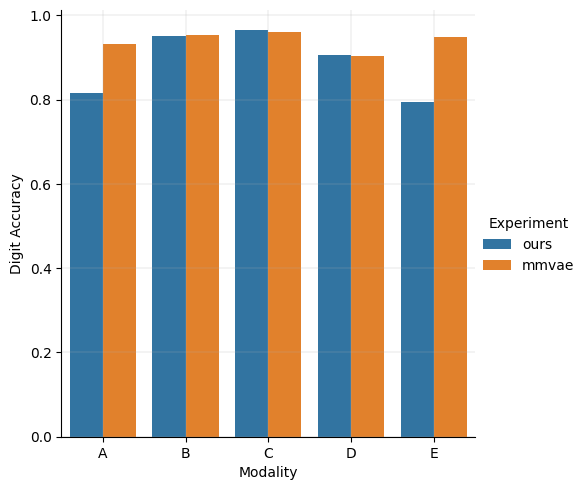

In [ ]:
results = {"Digit Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["polymnist"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Digit Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.catplot(results, x = "Modality", y = "Digit Accuracy", hue = "Experiment",
                   kind = "bar", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.show()

## CUB

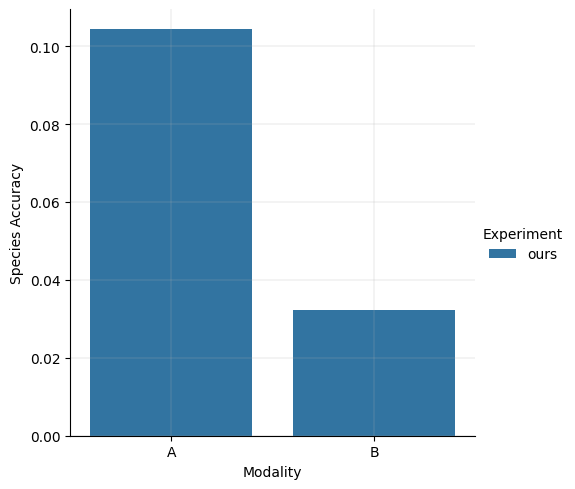

In [ ]:
results = {"Species Accuracy": [], "Modality": [], "Experiment": []}
for (exp_name, modal_dict) in accs["cub"].items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            fold_accs = list(fold_accs.values())
            results["Species Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
plot = sns.catplot(results, x = "Modality", y = "Species Accuracy", hue = "Experiment",
                   kind = "bar", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
plt.show()

# Covariances

In [14]:
label_maps = {
    "patchseq": {i: lambda sp_ids,i=i: patch_color_code(datasets["patchseq"], sp_ids, i)
                 for i in range(104)},
    "polymnist": {0: lambda sp_ids: datasets["polymnist"].get_specimens(sp_ids, outputs = ["class"])["class"]},
    "cub": {0: lambda sp_ids: datasets["cub"].get_specimens(sp_ids, outputs = ["class"])["class"]}
}

In [15]:
allowed_models = {"ours_2"}
allowed_datasets = {"patchseq"}

In [16]:
all_zs = {}

In [21]:
num_batches = {"patchseq": 1, "polymnist": 70, "cub": 50}
for (dataset_name, dataset_models) in models.items():
    if dataset_name not in allowed_datasets: 
        continue
    met_data = datasets[dataset_name]
    query = data_config[dataset_name]["query"]
    modal_forms = data_config[dataset_name]["modal_forms"]
    batches = num_batches[dataset_name]
    all_zs[dataset_name] = {}
    for (model_name, folds) in dataset_models.items():
        for (fold, fold_dict) in folds.items():
            combined_ids = np.concatenate([fold_dict["train_ids"], fold_dict["test_ids"]])
            for (in_modal, in_form) in modal_forms.items():
                samples = met_data.query(combined_ids, **query, outputs = ["specimen_id", modal_forms[in_modal]])
                z_batches = []
                for i in range(batches):
                    print(f"Running {model_name} on {dataset_name}: {in_modal} -> {fold} - {i + 1}/{batches}            ", end = "\r")
                    batch_samples = {form: arr[i::batches] for (form, arr) in samples.items()}
                    specimen_ids = batch_samples.pop("specimen_id")
                    (mean, transf) = fold_dict["model"](batch_samples, in_modal)
                    z_batches.append((specimen_ids, mean.numpy(force = True), transf.numpy(force = True)))
                specimen_ids = np.concatenate([sp_ids for (sp_ids, _, _) in z_batches], 0)
                z_means = np.concatenate([mean for (_, mean, _) in z_batches], 0)
                z_transf = np.concatenate([transf for (_, _, transf) in z_batches], 0)
                all_zs[dataset_name].setdefault(model_name, {}).setdefault(in_modal, {})[fold] = (specimen_ids, z_means, z_transf)

In [97]:
neighbors = 20
num_steps = 10

metric_affinities = {}
euclidean_affinities = {}
steps = np.linspace(0, 1, num_steps + 1)[1:]
for (dataset_name, data_dict) in all_zs.items():
    for (exp_name, exp_dict) in data_dict.items():
        for (in_modal, modal_dict) in exp_dict.items():
            for (fold, (specimen_ids, z_means, z_transf)) in modal_dict.items():
                num_samples = z_means.shape[0]
                nearest_indices = NearestNeighbors(n_neighbors = neighbors*5).fit(z_means).kneighbors()[1]
                (nn_means, nn_transf) = (z_means[nearest_indices], z_transf[nearest_indices])
                diff_vectors = nn_means - z_means[:, None]
                z_inv = np.linalg.inv(np.einsum("nij,nkj->nik", z_transf, z_transf))
                nn_inv = np.linalg.inv(np.einsum("nlij,nlkj->nlik", nn_transf, nn_transf))
                interp_invs = np.einsum("s,nlij->snlij", steps, z_inv[:, None]) + np.einsum("s,nlij->snlij", 1 - steps, nn_inv)
                dist = np.sqrt(np.einsum("nli,snlij,nlj->snl", diff_vectors, interp_invs, diff_vectors)).mean(0)
                nn_metric_indices = np.argsort(dist, -1)[:, :neighbors]
                metric_indices = nearest_indices[np.arange(num_samples)[:, None], nn_metric_indices]
                metric_dists = dist[np.arange(num_samples)[:, None], nn_metric_indices]

                metric_matrix = sprs.lil_array((num_samples, num_samples))
                metric_matrix[np.arange(num_samples)[:, None], metric_indices] = 1 / metric_dists
                metric_matrix = sprs.csc_matrix(metric_matrix + metric_matrix.T)

                euclidean_matrix = sprs.lil_array((num_samples, num_samples))
                euclidean_matrix[np.arange(num_samples)[:, None], nearest_indices[:, :neighbors]] = 1 / np.linalg.norm(diff_vectors[:, :neighbors], axis = -1)
                euclidean_matrix = sprs.csc_matrix(euclidean_matrix + euclidean_matrix.T)

                metric_affinities.setdefault(dataset_name, {}).setdefault(exp_name, {}).setdefault(in_modal, {})[fold] = metric_matrix
                euclidean_affinities.setdefault(dataset_name, {}).setdefault(exp_name, {}).setdefault(in_modal, {})[fold] = euclidean_matrix

In [100]:
modal = "T"
scores = []
for num_clusters in range(2, 104, 2):
    print(num_clusters)
    metric_clusters = SpectralClustering(n_clusters = num_clusters, affinity = "precomputed").fit_predict(metric_affinities["patchseq"]["ours"][modal][1])
    euc_clusters = SpectralClustering(n_clusters = num_clusters, affinity = "nearest_neighbors", n_neighbors = neighbors).fit_predict(all_zs["patchseq"]["ours"][modal][1][1])

    ours = adjusted_rand_score(labels, metric_clusters.astype(str))
    eucl = adjusted_rand_score(labels, euc_clusters.astype(str))
    scores.append((ours, eucl))

2


/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


4


/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


6


...

/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


100


/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


102


/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/ian.convy/miniconda3/envs/cpl/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


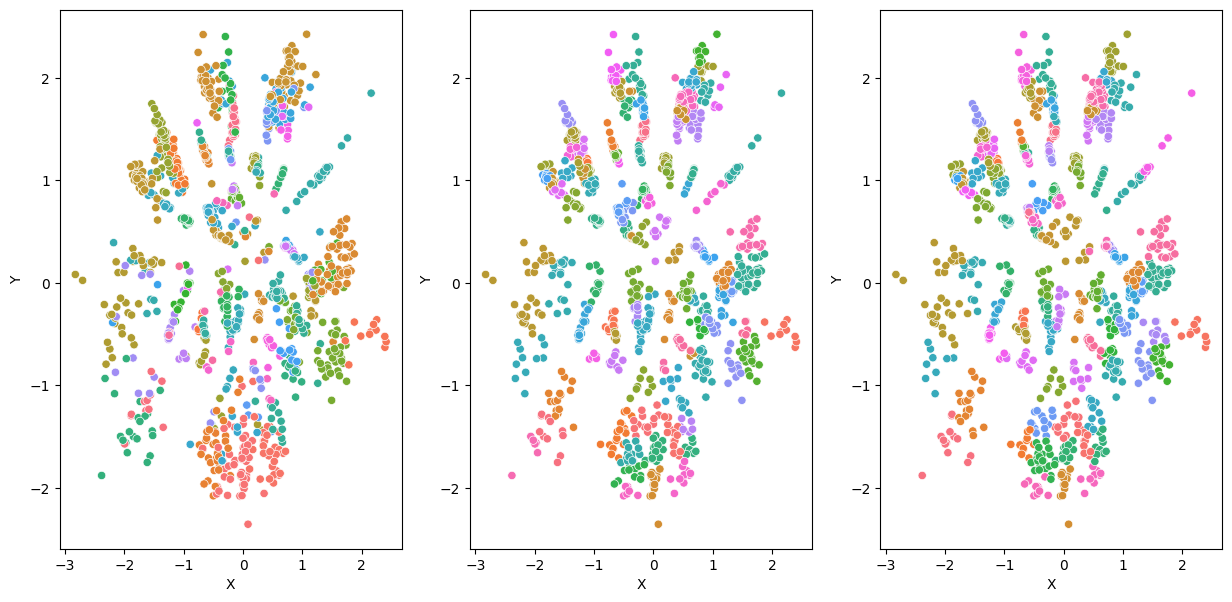

In [88]:

(fig, axes) = plt.subplots(ncols = 3, figsize = (15, 7))
z = all_zs["patchseq"]["ours"][modal][1][1]
labels = label_maps["patchseq"][103 - num_clusters](all_zs["patchseq"]["ours"][modal][1][0])
plot_data = {"X": z[:, 0], "Y": z[:, 1], "Metric": metric_clusters.astype(str), "Euclidean": euc_clusters.astype(str), "T-types": labels}
sns.scatterplot(data = plot_data, x = "X", y = "Y", hue = "T-types", ax = axes[0])
sns.scatterplot(data = plot_data, x = "X", y = "Y", hue = "Metric", ax = axes[1])
sns.scatterplot(data = plot_data, x = "X", y = "Y", hue = "Euclidean", ax = axes[2])
for ax in axes:
    ax.get_legend().set_visible(False)
plt.show()

In [101]:
scores

[(0.007689041402187981, 0.007689041402187981),
 (0.07214448629654635, 0.05826890274185995),
 (0.13124667347625701, 0.10712915701820039),
 (0.15655241960419247, 0.16838393847817473),
 (0.1521149467859127, 0.2429405076222594),
 (0.2662827378964761, 0.3193976115744262),
 (0.3188903445330075, 0.32891953403417334),
 (0.36455562860329166, 0.3776911152242718),
 (0.3796874896118065, 0.42843810098191487),
 (0.4332699517518823, 0.42841723296276973),
 (0.4268435957822088, 0.43985851099436407),
 (0.4574284413817151, 0.4568776914171729),
 (0.4551031569312948, 0.4985422768259149),
 (0.5331755666797804, 0.5229251616593734),
 (0.5489788952897894, 0.5455139733969507),
 (0.5512256142562721, 0.5244915139241333),
 (0.5642223367276008, 0.5200741685326975),
 (0.5393654834905841, 0.5251589175648314),
 (0.5473953518331579, 0.535001845803938),
 (0.5365877136171705, 0.5287389769328055),
 (0.5343480365831791, 0.5171027346732956),
 (0.5460955822871117, 0.5187067225153016),
 (0.511507075483167, 0.5037887022662797)